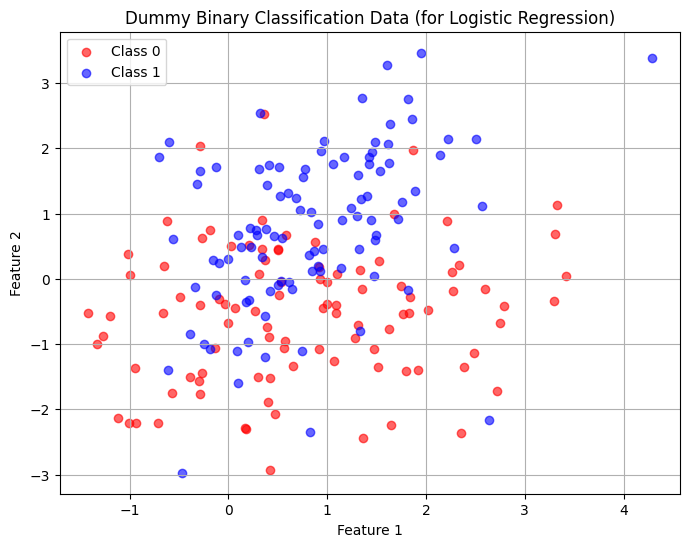

Features shape: (200, 2)
Target shape: (200,)


In [99]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification


# Set seed
np.random.seed(42)

# Generate a classification dataset
x, y = make_classification(
    n_samples=200,
    n_features=2,          # Only 2 useful features for visualization
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.8,         # Low separation makes it harder
    flip_y=0.1,            # Add noise (10% label flipping)
    random_state=42
)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print("Features shape:", x.shape)
print("Target shape:", y.shape)

In [100]:
w= np.random.rand(1,2)
b= np.array([[0]])
y = y.reshape(-1,1)
print(x.shape,y.shape,w.shape)
y_=(1/(1+np.exp(w@x.T+b))).T
print(y_.shape)

(200, 2) (200, 1) (1, 2)
(200, 1)


In [101]:
num_samples=200

cost = -(1/(num_samples*(np.sum(y*np.log(y_)+(1-y)*np.log(1-y_)))))
print(cost)


2.0200637490623898e-05


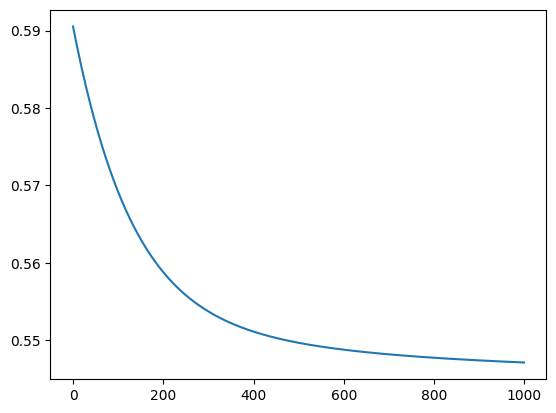

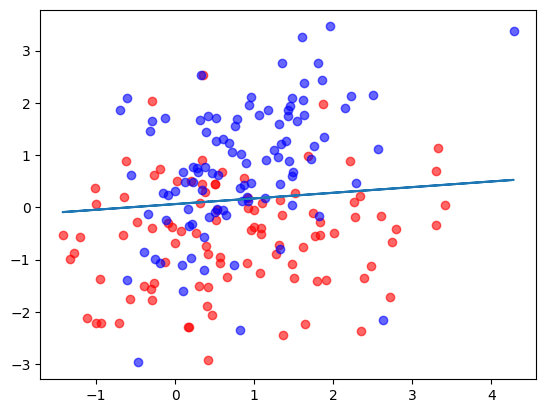

In [102]:
cost_history=[]
learning_rate =0.01
for i in range (1000):
    z=w@x.T+b
    y_pred=1/(1+np.exp(-z))
    error=y_pred-y.T
    djdw= (1/num_samples)*error@x
    djdb= (np.sum(error/num_samples))
    w=w-learning_rate*djdw
    b=b-learning_rate*djdb
    cost = -(1/num_samples)*np.sum(y*np.log(y_pred.T)+(1-y)*np.log(1-y_pred.T))
    cost_history.append(cost)
    
plt.plot(cost_history)
plt.show()

x1 = x[:, 0]
x2 = (-b[0][0] - w[0][0] * x1) / w[0][1]

plt.scatter(x[y[:, 0] == 0][:, 0], x[y[:, 0] == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(x[y[:, 0] == 1][:, 0], x[y[:, 0] == 1][:, 1], color="blue", label="Class 1", alpha=0.6)

plt.plot(x1, x2)
plt.show()

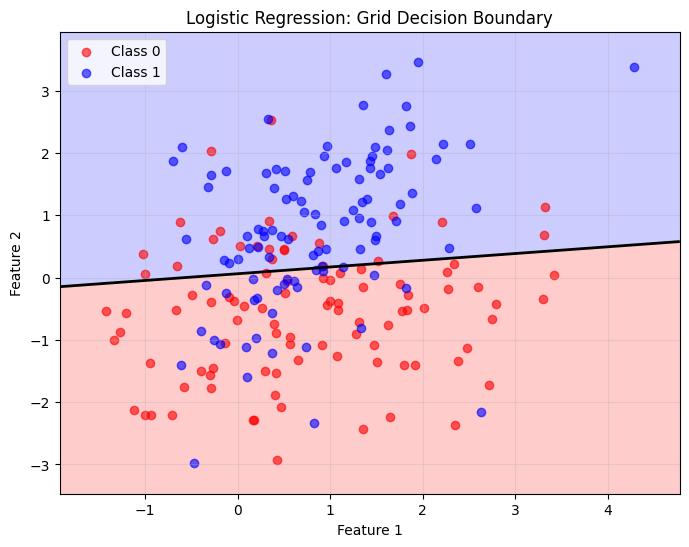

In [103]:
# 1. Grid (Meshgrid) taiyar karna poore graph ki range par
x_min, x_max = x[:, 0].min() - 0.5, x[:, 0].max() + 0.5
y_min, y_max = x[:, 1].min() - 0.5, x[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 2. Grid ke har ek point par model se prediction (Probability) nikalna
grid_points = np.c_[xx.ravel(), yy.ravel()]
z_grid = w @ grid_points.T + b
preds_grid = 1 / (1 + np.exp(-z_grid))
preds_grid = preds_grid.reshape(xx.shape)

# 3. Plotting shuru karna
plt.figure(figsize=(8, 6))

# Background grid ka rang (Decision Regions)
plt.contourf(xx, yy, preds_grid, levels=[0, 0.5, 1], alpha=0.2, colors=['red', 'blue'])
# 0.5 waali boundary line ko dark khinchna
plt.contour(xx, yy, preds_grid, levels=[0.5], colors='black', linewidths=2)

# Asli data points ko upar se scatter karna
plt.scatter(x[y[:, 0] == 0, 0], x[y[:, 0] == 0, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(x[y[:, 0] == 1, 0], x[y[:, 0] == 1, 1], color="blue", label="Class 1", alpha=0.6)

plt.title("Logistic Regression: Grid Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()